X: (1941, 27) | y: (1941, 7)
Train: (1358, 27)
Validation: (291, 27)
Test: (292, 27)
Epoch 0 | Train Loss: 1.9461 | Val Loss: 1.9416
Epoch 50 | Train Loss: 1.7578 | Val Loss: 1.7420
Epoch 100 | Train Loss: 1.4690 | Val Loss: 1.4431
Epoch 150 | Train Loss: 1.3600 | Val Loss: 1.3323
Epoch 200 | Train Loss: 1.2903 | Val Loss: 1.2612
Epoch 250 | Train Loss: 1.2336 | Val Loss: 1.2008
Epoch 300 | Train Loss: 1.1752 | Val Loss: 1.1410
Epoch 350 | Train Loss: 1.1096 | Val Loss: 1.0770
Epoch 400 | Train Loss: 1.0382 | Val Loss: 1.0083
Epoch 450 | Train Loss: 0.9747 | Val Loss: 0.9485
Epoch 500 | Train Loss: 0.9241 | Val Loss: 0.9025
Epoch 550 | Train Loss: 0.8832 | Val Loss: 0.8660

Accuracy en test: 0.726027397260274


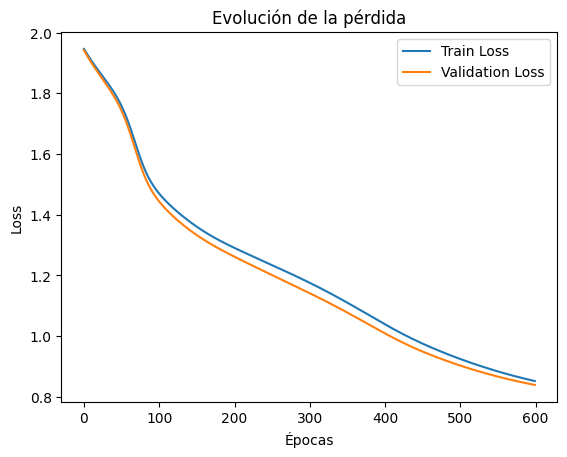

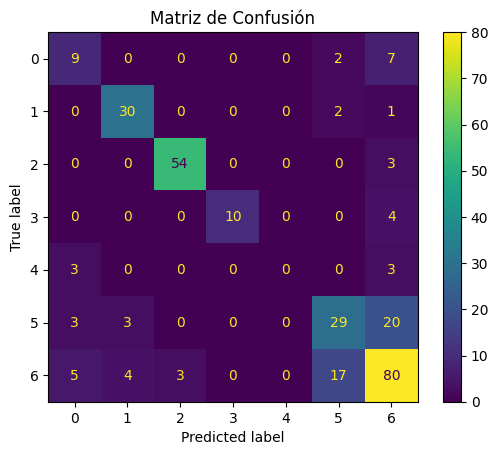

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================================
# CARGA DE DATOS
# =========================================
PROCESSED_FILE = Path("../data/processed/faults_processed.csv")

if not PROCESSED_FILE.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {PROCESSED_FILE}")

df = pd.read_csv(PROCESSED_FILE)

X = df.iloc[:, :27].values
y = df.iloc[:, 27:].values

print("X:", X.shape, "| y:", y.shape)


# =========================================
# SPLIT: TRAIN / VALIDATION / TEST
# =========================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# =========================================
# MODELO MLP CON EARLY STOPPING
# =========================================
class MLP:
    def __init__(self, input_size, hidden_size, output_size, lr=0.05, epochs=3000, patience=20):
        self.lr = lr
        self.epochs = epochs
        self.patience = patience

        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        self.train_loss = []
        self.val_loss = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.softmax(self.z2)

        return self.a2

    def compute_loss(self, y, y_pred):
        m = y.shape[0]
        return -np.sum(y * np.log(y_pred + 1e-8)) / m

    def backward(self, X, y):
        m = X.shape[0]

        dz2 = self.a2 - y
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = (dz2 @ self.W2.T) * self.relu_deriv(self.z1)
        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X_train, y_train, X_val, y_val):
        best_val_loss = float("inf")
        patience_counter = 0

        for epoch in range(self.epochs):
            # Forward train
            y_pred_train = self.forward(X_train)
            loss_train = self.compute_loss(y_train, y_pred_train)
            self.train_loss.append(loss_train)

            # Backprop
            self.backward(X_train, y_train)

            # Forward validation
            y_pred_val = self.forward(X_val)
            loss_val = self.compute_loss(y_val, y_pred_val)
            self.val_loss.append(loss_val)

            # Early stopping
            if loss_val < best_val_loss:
                best_val_loss = loss_val
                patience_counter = 0
            else:
                patience_counter += 1

            if epoch % 50 == 0:
                print(f"Epoch {epoch} | Train Loss: {loss_train:.4f} | Val Loss: {loss_val:.4f}")

            if patience_counter >= self.patience:
                print(f"Early stopping en epoch {epoch}")
                break

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)


# =========================================
# ENTRENAMIENTO
# =========================================
mlp = MLP(input_size=27, hidden_size=64, output_size=7, lr=0.05, epochs=600)

mlp.fit(X_train, y_train, X_val, y_val)


# =========================================
# EVALUACIÓN FINAL (TEST)
# =========================================
y_pred = mlp.predict(X_test)
y_true = y_test.argmax(axis=1)

accuracy = (y_pred == y_true).mean()
print("\nAccuracy en test:", accuracy)


# =========================================
# GRÁFICA DE PÉRDIDA
# =========================================
plt.figure()
plt.plot(mlp.train_loss, label="Train Loss")
plt.plot(mlp.val_loss, label="Validation Loss")
plt.title("Evolución de la pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()


# =========================================
# MATRIZ DE CONFUSIÓN
# =========================================
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión")
plt.show()